In [12]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

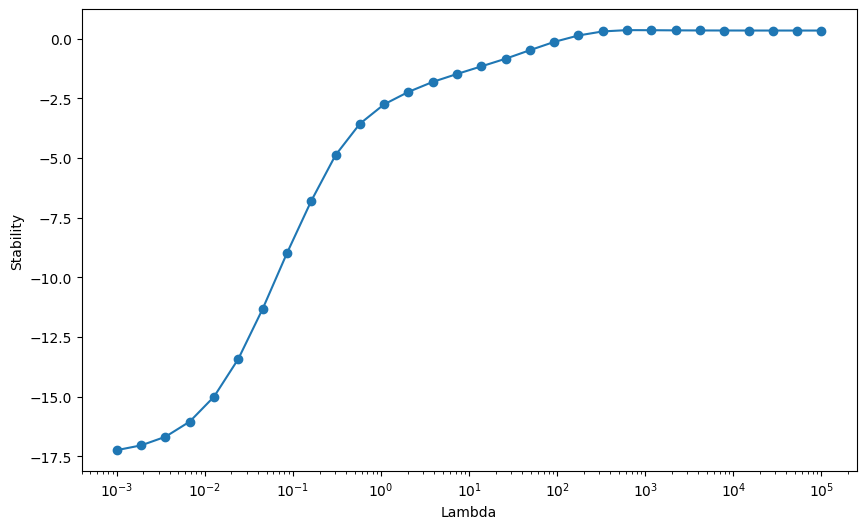

In [45]:
df = pd.read_csv("results/results_synthetic.csv")
plt.figure(figsize=(10, 6))
df = df[df['lambda'] > 0]
plt.plot(df['lambda'].values, np.array(1 - df['instability']), marker='o')
plt.xlabel('Lambda')
plt.ylabel('Stability')
plt.xscale('log')
plt.show()

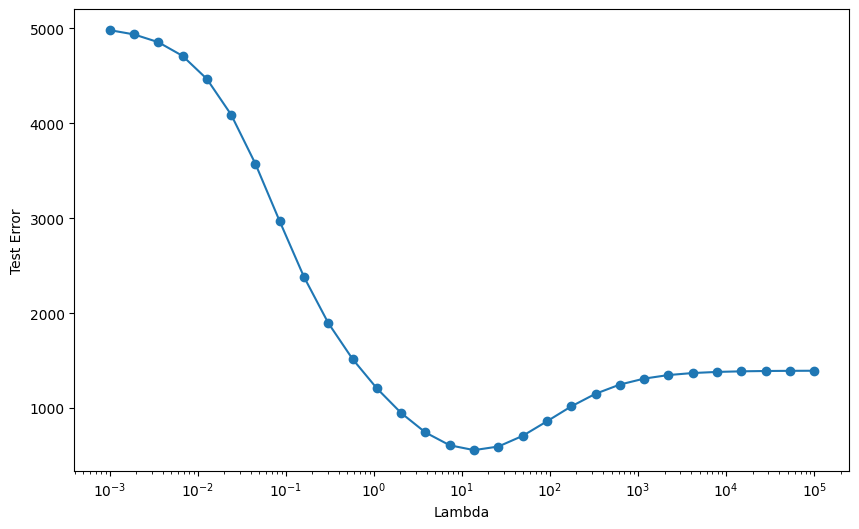

In [46]:
plt.figure(figsize=(10, 6))
plt.plot(df['lambda'].values, df['test_error'].values, marker='o')
plt.xlabel('Lambda')
plt.ylabel('Test Error')
plt.xscale('log')
plt.show()

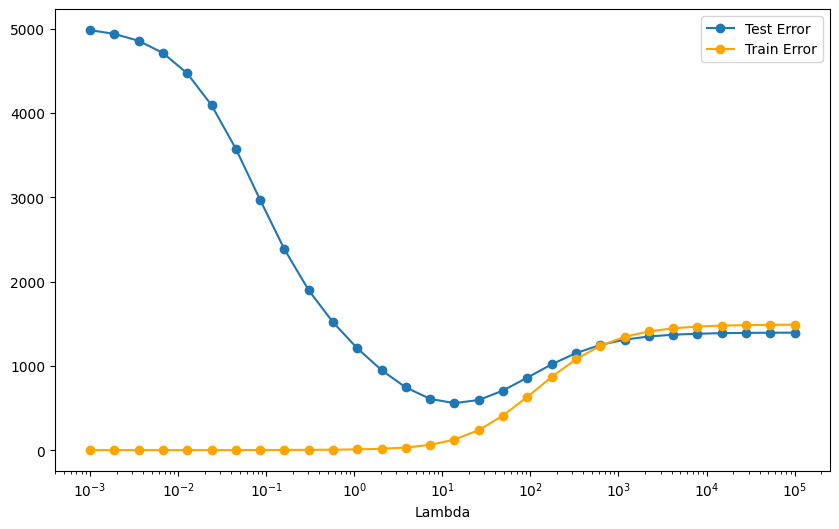

In [47]:
plt.figure(figsize=(10, 6))
plt.plot(df['lambda'].values, df['test_error'].values, marker='o')
plt.plot(df['lambda'].values, df['train_error'].values, marker='o', color='orange')
plt.xlabel('Lambda')
plt.xscale('log')
plt.legend(['Test Error', 'Train Error'])
plt.show()

In [49]:
ols_model = df.iloc[0]

best_ridge_idx = df['test_error'].idxmin()
best_ridge_model = df.iloc[best_ridge_idx]

worst_ridge_model = df.iloc[-1]

medium_idx = best_ridge_idx // 2
medium_ridge_model = df.iloc[medium_idx]

print("--- ANALISI DELL'IMPATTO DI LAMBDA ---")
print(f"1. OLS (No Reg, L=0)          -> Test Error: {ols_model['test_error']:.2f} | Instabilità: {ols_model['instability']:.2f}")
print(f"2. Ridge Medio (L={medium_ridge_model['lambda']:.2f})    -> Test Error: {medium_ridge_model['test_error']:.2f} | Instabilità: {medium_ridge_model['instability']:.2f}")
print(f"3. BEST RIDGE (L={best_ridge_model['lambda']:.2f})     -> Test Error: {best_ridge_model['test_error']:.2f} | Instabilità: {best_ridge_model['instability']:.2f}")
print(f"4. Ridge Pessimo (L={worst_ridge_model['lambda']:.2f}) -> Test Error: {worst_ridge_model['test_error']:.2f} | Instabilità: {worst_ridge_model['instability']:.2f} (UNDERFITTING)")

--- ANALISI DELL'IMPATTO DI LAMBDA ---
1. OLS (No Reg, L=0)          -> Test Error: 32811.49 | Instabilità: 278.46
2. Ridge Medio (L=0.09)    -> Test Error: 2968.87 | Instabilità: 9.99
3. BEST RIDGE (L=13.74)     -> Test Error: 557.07 | Instabilità: 2.17
4. Ridge Pessimo (L=100000.00) -> Test Error: 1393.53 | Instabilità: 0.67 (UNDERFITTING)


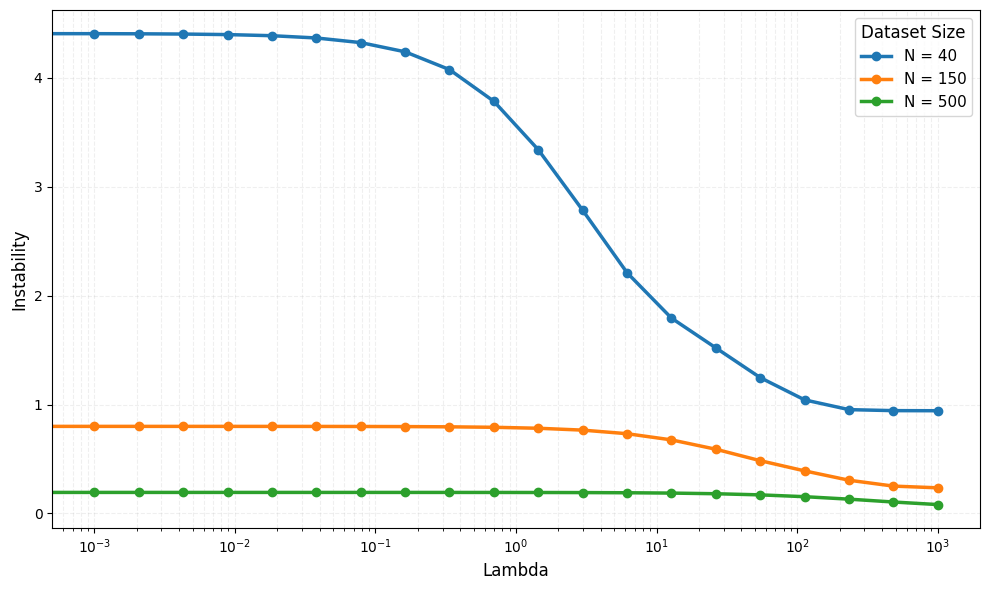

In [58]:
df_size = pd.read_csv('results/results_dataset_size.csv')

sizes = df_size['N'].unique()

plt.figure(figsize=(10, 6))
colors = ['tab:blue', 'tab:orange', 'tab:green']

for i, N in enumerate(sizes):
    df_subset = df_size[df_size['N'] == N]
    
    plt.plot(
        df_subset['lambda'], 
        df_subset['instability'], 
        marker='o', 
        linewidth=2.5, 
        label=f'N = {int(N)}', 
        color=colors[i % len(colors)]
    )

plt.xscale('log')
plt.xlabel('Lambda', fontsize=12)
plt.ylabel('Instability', fontsize=12)

plt.legend(title="Dataset Size", fontsize=11, title_fontsize=12)
plt.grid(True, which="both", ls="--", alpha=0.2)

plt.tight_layout()
plt.show()